Fontconfig warning: We will not regenerate the cache because some cache files were generated by a newer version (0x2012003) of Fontconfig. Please regenerate the cache with the latest version of Fontconfig to avoid any unexpected behavior. (current version: 0x2012002)


w is:  1.5933633756656984
b is:  -8.5604260548949
cost is:  117.28701351904957


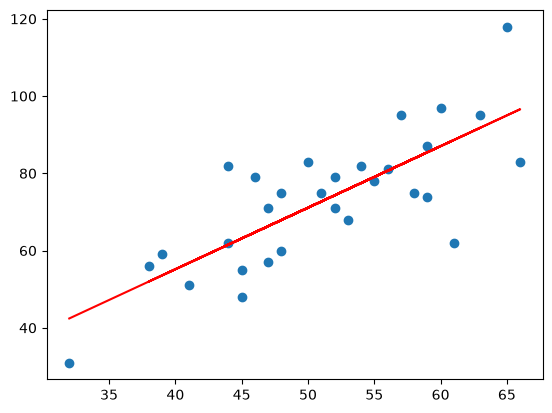

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
 
# ---------------1. 准备数据----------
data = np.array(
    [[32,31],[53,68],[61,62],[47,71],[59,87],[55,78],[52,79],[39,59],
     [48,75],[52,71],[45,55],[54,82],[44,62],[58,75],[56,81],[48,60],
     [44,82],[60,97],[45, 48],[38,56],[66,83],[65,118],[47,57],[41,51],[51,75],[59,74],[57,95],[63,95],[46,79],[50,83]])
 
# 提取data中的两列数据，分别作为x，y
x = data[:, 0]
y = data[:, 1]
 
# 用plt画出散点图
#plt.scatter(x, y)
#plt.show()
 
# -----------2. 定义损失函数------------------
# 损失函数是系数的函数，另外还要传入数据的x，y
def compute_cost(w, b, points):
    total_cost = 0
    M = len(points)
 
    # 逐点计算平方损失误差，然后求平均数
    for i in range(M):
        x = points[i, 0]
        y = points[i, 1]
        total_cost += (y - w * x - b) ** 2
 
    return total_cost / M
 
# ------------3.定义算法拟合函数-----------------
# 先定义一个求均值的函数
def average(data):
    sum = 0
    num = len(data)
    for i in range(num):
        sum += data[i]
    return sum / num
 
# 定义核心拟合函数
def fit(points):
    M = len(points)
    x_bar = average(points[:, 0])
 
    sum_yx = 0
    sum_x2 = 0
    sum_delta = 0
 
    for i in range(M):
        x = points[i, 0]
        y = points[i, 1]
        sum_yx += y * (x - x_bar)
        sum_x2 += x ** 2
    # 根据公式计算w
    a = sum_yx / (sum_x2 - M * (x_bar ** 2))
 
    for i in range(M):
        x = points[i, 0]
        y = points[i, 1]
        sum_delta += (y - a * x)
    b = sum_delta / M
 
    return a, b
 
# ------------4. 测试------------------
w, b = fit(data)
 
print("w is: ", w)
print("b is: ", b)
 
cost = compute_cost(w, b, data)
 
print("cost is: ", cost)
 
# ---------5. 画出拟合曲线------------
plt.scatter(x, y)
# 针对每一个x，计算出预测的y值
pred_y = w * x + b
 
plt.plot(x, pred_y, c='r')
plt.show()


w is:  1.5933633756657108
b is:  -8.56042605489553
cost is:  117.28701351904957


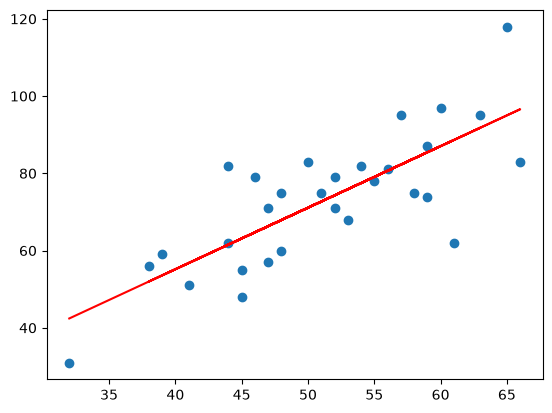

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
 
# -------------1. 数据---------
#points = np.genfromtxt('data.csv', delimiter=',')
data = np.array([[32, 31], [53, 68], [61, 62], [47, 71], [59, 87], [55, 78], [52, 79], [39, 59], [48, 75], [52, 71],
                     [45, 55], [54, 82], [44, 62], [58, 75], [56, 81], [48, 60], [44, 82], [60, 97], [45, 48], [38, 56],
                     [66, 83], [65, 118], [47, 57], [41, 51], [51, 75], [59, 74], [57, 95], [63, 95], [46, 79],
                     [50, 83]])
# 提取points中的两列数据，分别作为x，y
x = data[:, 0]
y = data[:, 1]
 
# --------------2. 定义损失函数--------------
# 损失函数是系数的函数，另外还要传入数据的x，y
def compute_cost(w, b, data):
    total_cost = 0
    M = len(data)
    # 逐点计算平方损失误差，然后求平均数
    for i in range(M):
        x = data[i, 0]
        y = data[i, 1]
        total_cost += (y - w * x - b) ** 2
    return total_cost / M
 
lr = LinearRegression()  # 继承类，创立线性回归对象
x_new = x.reshape(-1, 1)
y_new = y.reshape(-1, 1)
lr.fit(x_new, y_new)
# 从训练好的模型中提取系数和偏置
w = lr.coef_[0][0]
b = lr.intercept_[0]
print("w is: ", w)
print("b is: ", b)
cost = compute_cost(w, b, data)
print("cost is: ", cost)
plt.scatter(x, y)
# 针对每一个x，计算出预测的y值
pred_y = w * x + b
plt.plot(x, pred_y, c='r')
plt.show()